# Notebook 3 — Baseline LSTM (The Challenger)

**Project:** AlphaCast — Sector-Augmented Time-Series Transformers for Financial Forecasting

## Goal
Train a **standard PyTorch LSTM** on the windows produced by Notebook 2 to forecast the next **7 daily Close prices**. Evaluate it on the unseen 20% test set with **RMSE** and **MAPE**, then save:
- `models/lstm_model.pt`            — trained weights
- `artifacts/<STOCK>_processed/lstm_metrics.json` — RMSE, MAPE
- `artifacts/<STOCK>_processed/lstm_predictions.npy` — test-set predictions (dollars)

## Architecture (kept deliberately simple — easy to defend in viva)
```
Input  : (batch, 30, 14)   <- 30-day lookback, 14 features (stock + ETF + indicators)
  │
LSTM   : 2 stacked layers, hidden=64, dropout=0.2
  │
FC     : Linear(64 -> 7)   <- one neuron per future day
  │
Output : (batch, 7)        <- next 7 scaled Close values
```
Loss = **MSE** (regression). Optimiser = **Adam**.

In [1]:
# ----------------------------------------------------------------------
# Cell 1 : Imports & determinism
# ----------------------------------------------------------------------
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps'  if torch.backends.mps.is_available()
                      else 'cpu')
print('Using device:', device)

Using device: mps


In [2]:
# ----------------------------------------------------------------------
# Cell 2 : Load the artifacts produced by Notebook 2
# ----------------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS    = os.path.join(PROJECT_ROOT, 'artifacts')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

TARGET_STOCK = 'AAPL'    # must match Notebooks 1 & 2
DATA_DIR     = os.path.join(ARTIFACTS, f'{TARGET_STOCK}_processed')

with open(os.path.join(DATA_DIR, 'config.json')) as f:
    cfg = json.load(f)
print(json.dumps(cfg, indent=2))

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
with open(os.path.join(DATA_DIR, 'target_scaler.pkl'), 'rb') as f:
    target_scaler = pickle.load(f)

print('Shapes :', X_train.shape, y_train.shape, X_test.shape, y_test.shape)

{
  "stock": "AAPL",
  "matched_etf": "XLK",
  "sector": "Technology",
  "feature_cols": [
    "Close",
    "Open",
    "High",
    "Low",
    "Volume",
    "STK_MA7",
    "STK_MA21",
    "STK_RSI",
    "STK_MACD",
    "ETF_Close",
    "ETF_MA7",
    "ETF_MA21",
    "ETF_RSI",
    "ETF_MACD"
  ],
  "target_col": "Close",
  "target_col_index": 0,
  "lookback": 30,
  "horizon": 7,
  "test_fraction": 0.2,
  "n_features": 14,
  "train_samples": 2508,
  "test_samples": 601,
  "train_date_start": "2005-03-28",
  "train_date_end": "2015-05-05",
  "test_date_start": "2015-05-06",
  "test_date_end": "2017-11-10"
}
Shapes : (2508, 30, 14) (2508, 7) (601, 30, 14) (601, 7)


In [3]:
# ----------------------------------------------------------------------
# Cell 3 : Hyper-parameters
# ----------------------------------------------------------------------
INPUT_DIM   = cfg['n_features']      # 14
HIDDEN_DIM  = 64
NUM_LAYERS  = 2
DROPOUT     = 0.2
OUTPUT_DIM  = cfg['horizon']         # 7

BATCH_SIZE  = 64
EPOCHS      = 40
LR          = 1e-3
VAL_FRAC    = 0.10                   # carve a small validation set out of TRAIN (chronological)

# --- Build train / val tensors (NO SHUFFLE — keep chronological order) ---
n_val      = int(len(X_train) * VAL_FRAC)
X_tr, X_val = X_train[:-n_val], X_train[-n_val:]
y_tr, y_val = y_train[:-n_val], y_train[-n_val:]

def to_loader(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)

# We DO shuffle the training mini-batches (not the chronological split itself).
train_loader = to_loader(X_tr, y_tr,  shuffle=True)
val_loader   = to_loader(X_val, y_val, shuffle=False)
test_loader  = to_loader(X_test, y_test, shuffle=False)

print(f'Train: {len(X_tr)}  | Val: {len(X_val)}  | Test: {len(X_test)}')

Train: 2258  | Val: 250  | Test: 601


In [4]:
# ----------------------------------------------------------------------
# Cell 4 : The LSTM model
# ----------------------------------------------------------------------
class LSTMForecaster(nn.Module):
    """
    Vanilla 2-layer LSTM. We take only the LAST time-step's hidden state
    and project it through a fully-connected head into a 7-day forecast.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x : (B, T, F)
        out, _ = self.lstm(x)         # out: (B, T, H)
        last   = out[:, -1, :]        # (B, H)  -- final timestep
        return self.fc(last)          # (B, output_dim)

model = LSTMForecaster(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM, DROPOUT).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters : {n_params:,}')

LSTMForecaster(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)
Trainable parameters : 54,215


In [5]:
# ----------------------------------------------------------------------
# Cell 5 : Training loop with early-stopping on validation loss
# ----------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val   = float('inf')
patience   = 7
since_best = 0
history    = {'train_loss': [], 'val_loss': []}
best_state = None

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # ---- validate ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_losses.append(criterion(model(xb), yb).item())

    tr_l, va_l = float(np.mean(train_losses)), float(np.mean(val_losses))
    history['train_loss'].append(tr_l); history['val_loss'].append(va_l)
    print(f'Epoch {epoch:3d} | train {tr_l:.5f} | val {va_l:.5f}')

    # ---- early stopping ----
    if va_l < best_val - 1e-6:
        best_val   = va_l
        since_best = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        since_best += 1
        if since_best >= patience:
            print(f'Early-stopping at epoch {epoch} (best val {best_val:.5f})')
            break

print(f'Training time: {time.time()-t0:.1f}s')
if best_state is not None:
    model.load_state_dict(best_state)

Epoch   1 | train 0.01829 | val 0.12386
Epoch   2 | train 0.00095 | val 0.12202
Epoch   3 | train 0.00068 | val 0.11456
Epoch   4 | train 0.00061 | val 0.11130
Epoch   5 | train 0.00058 | val 0.11106
Epoch   6 | train 0.00058 | val 0.10827
Epoch   7 | train 0.00056 | val 0.10388
Epoch   8 | train 0.00055 | val 0.10253
Epoch   9 | train 0.00055 | val 0.09040
Epoch  10 | train 0.00055 | val 0.09252
Epoch  11 | train 0.00050 | val 0.08949
Epoch  12 | train 0.00049 | val 0.08957
Epoch  13 | train 0.00048 | val 0.08789
Epoch  14 | train 0.00052 | val 0.09310
Epoch  15 | train 0.00050 | val 0.08947
Epoch  16 | train 0.00044 | val 0.08434
Epoch  17 | train 0.00045 | val 0.08819
Epoch  18 | train 0.00048 | val 0.08446
Epoch  19 | train 0.00041 | val 0.08344
Epoch  20 | train 0.00044 | val 0.08122
Epoch  21 | train 0.00046 | val 0.08571
Epoch  22 | train 0.00043 | val 0.07915
Epoch  23 | train 0.00046 | val 0.07698
Epoch  24 | train 0.00037 | val 0.07797
Epoch  25 | train 0.00034 | val 0.07519


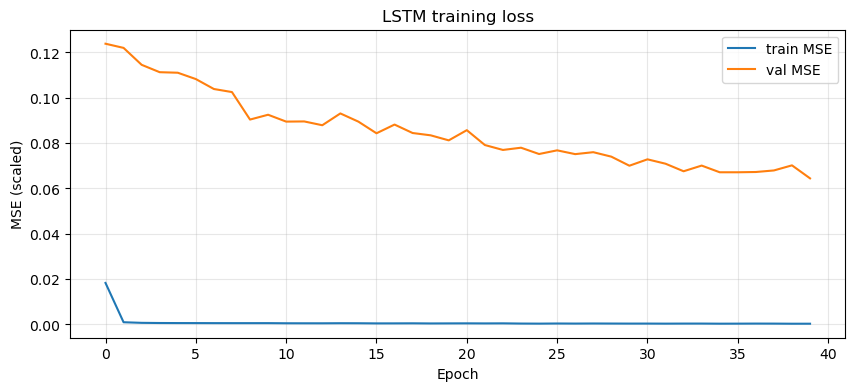

In [6]:
# ----------------------------------------------------------------------
# Cell 6 : Loss curve
# ----------------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(history['train_loss'], label='train MSE')
plt.plot(history['val_loss'],   label='val MSE')
plt.title('LSTM training loss')
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [7]:
# ----------------------------------------------------------------------
# Cell 7 : Test-set evaluation -> dollars
# ----------------------------------------------------------------------
model.eval()
preds_scaled, trues_scaled = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds_scaled.append(model(xb).cpu().numpy())
        trues_scaled.append(yb.numpy())
preds_scaled = np.concatenate(preds_scaled, axis=0)   # (N_test, 7)
trues_scaled = np.concatenate(trues_scaled, axis=0)

# Inverse-transform 7-day vectors back to dollars using the target_scaler
def inverse(arr2d):
    flat = arr2d.reshape(-1, 1)
    return target_scaler.inverse_transform(flat).reshape(arr2d.shape)

preds_usd = inverse(preds_scaled)
trues_usd = inverse(trues_scaled)

# --- metrics ---
rmse = float(np.sqrt(np.mean((preds_usd - trues_usd) ** 2)))
mape = float(np.mean(np.abs((preds_usd - trues_usd) / trues_usd)) * 100)

print(f'TEST RMSE : ${rmse:.4f}')
print(f'TEST MAPE : {mape:.4f} %')

TEST RMSE : $40.9776
TEST MAPE : 26.9493 %


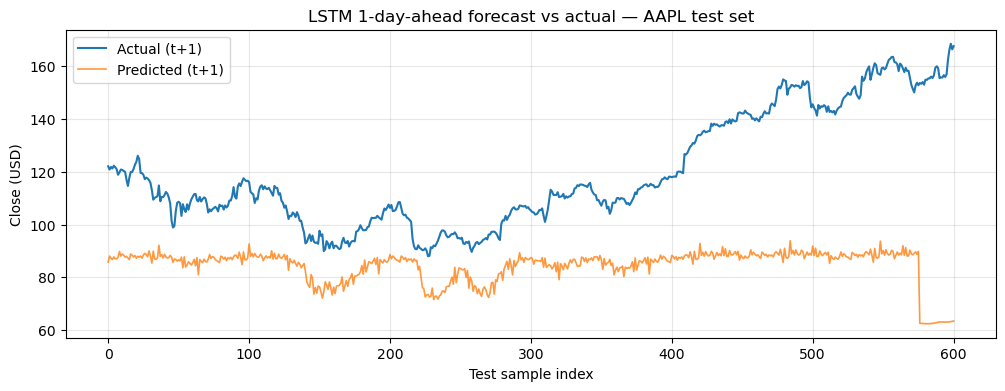

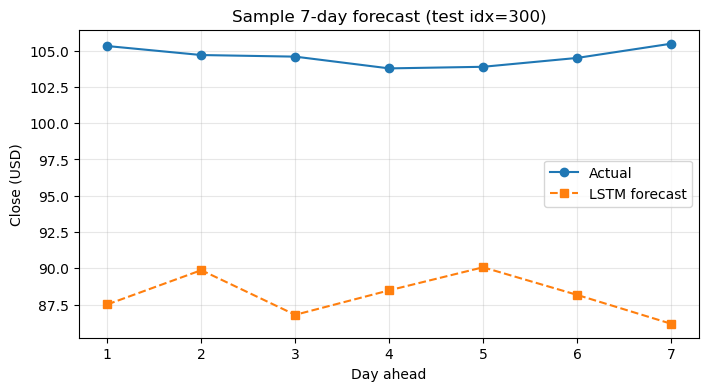

In [8]:
# ----------------------------------------------------------------------
# Cell 8 : Visualise prediction quality
# ----------------------------------------------------------------------
# (a) day-1-ahead predictions across the whole test timeline
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(trues_usd[:, 0], label='Actual (t+1)', linewidth=1.5)
ax.plot(preds_usd[:, 0], label='Predicted (t+1)', linewidth=1.2, alpha=0.8)
ax.set_title(f'LSTM 1-day-ahead forecast vs actual — {TARGET_STOCK} test set')
ax.set_xlabel('Test sample index'); ax.set_ylabel('Close (USD)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

# (b) zoom on a single 7-day forecast
i = len(preds_usd) // 2
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1, 8), trues_usd[i], 'o-', label='Actual')
ax.plot(range(1, 8), preds_usd[i], 's--', label='LSTM forecast')
ax.set_title(f'Sample 7-day forecast (test idx={i})')
ax.set_xlabel('Day ahead'); ax.set_ylabel('Close (USD)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

In [9]:
# ----------------------------------------------------------------------
# Cell 9 : Persist model, predictions, and metrics
# ----------------------------------------------------------------------
model_path = os.path.join(MODELS_DIR, 'lstm_model.pt')
torch.save({
    'state_dict' : model.state_dict(),
    'arch' : {
        'input_dim'  : INPUT_DIM,
        'hidden_dim' : HIDDEN_DIM,
        'num_layers' : NUM_LAYERS,
        'output_dim' : OUTPUT_DIM,
        'dropout'    : DROPOUT,
    },
    'stock' : TARGET_STOCK,
}, model_path)
print('Saved model ->', model_path)

np.save(os.path.join(DATA_DIR, 'lstm_predictions.npy'), preds_usd)
np.save(os.path.join(DATA_DIR, 'lstm_actuals.npy'),     trues_usd)

metrics = {
    'model'    : 'LSTM',
    'stock'    : TARGET_STOCK,
    'rmse_usd' : rmse,
    'mape_pct' : mape,
    'horizon'  : OUTPUT_DIM,
    'lookback' : cfg['lookback'],
    'n_test_windows' : int(len(preds_usd)),
    'n_params' : int(n_params),
    'best_val_mse_scaled' : float(best_val),
}
with open(os.path.join(DATA_DIR, 'lstm_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

Saved model -> /Users/parasbeniwal/sem8_project/models/lstm_model.pt
{
  "model": "LSTM",
  "stock": "AAPL",
  "rmse_usd": 40.977638244628906,
  "mape_pct": 26.949325561523438,
  "horizon": 7,
  "lookback": 30,
  "n_test_windows": 601,
  "n_params": 54215,
  "best_val_mse_scaled": 0.06444327248027548
}


## Recap (for the viva)

- 2-layer LSTM (hidden 64, dropout 0.2) — small enough to train on CPU in minutes, large enough to learn 30-day patterns.
- Trained with **MSE + Adam** on chronologically split train/val.
- **Early stopping** on validation loss prevents overfitting.
- Predictions inverse-transformed back to USD before computing **RMSE & MAPE** — these are the numbers we will compare against the Transformer in Notebook 4.
- Saved `lstm_model.pt`, predictions, and `lstm_metrics.json` for the showdown.